Number of results in clang_axtls_transformation is 332
Number of results in clang_busybox_transformation is 4
Number of results in clang_toybox_transformation is 80
Number of results in infer_axtls_transformation is 92
Number of results in infer_toybox_transformation is 103
Total number of alarms for transformation is 544
Number of results in clang_axtls_product is 19
Number of results in clang_busybox_product is 322
Number of results in clang_toybox_product is 82
Number of results in infer_axtls_product is 16
Number of results in infer_busybox_product is 0
Number of results in infer_toybox_product is 54
Total number of alarms for product is 472
Number of results in axtls_family is 1039
Number of results in busybox_family is 940
Number of results in toybox_family is 336
Total number of alarms for family is 833


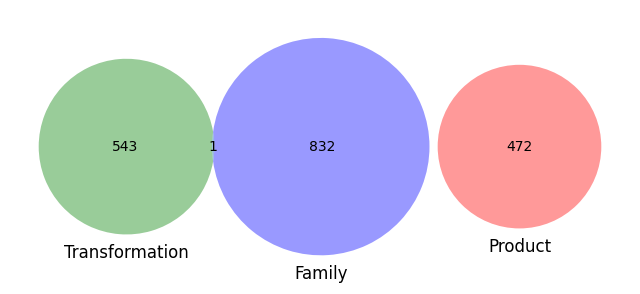

In [3]:
import os
import json
from taxonomy import get_warning_type
strats: dict[str, set] = {}
for strat in ["transformation", "product", "family"]:
  strats[strat] = set()
  if strat == "transformation" or strat == "product":
    for tool in ["clang", "infer"]:
      for target in ["axtls", "busybox", "toybox"]:
        path = f"../results_rw/{tool}_{target}_{strat}/results.json"
        if os.path.exists(path):
          with open(path, 'r') as inf:
            res = json.load(inf)
            print(f"Number of results in {tool}_{target}_{strat} is {len(res)}")
            for r in res:
              if strat == 'product':
                fl = r['originalAlarm']['fileLocation']
                line = (r['originalAlarm']['line'], r['originalAlarm']['line'])
                typ = get_warning_type(r)
                key = (fl, line, typ)
                strats[strat].add(key)
              else:
                key = (os.path.basename(r['originalFile']), tuple(r['lineInputFile']), get_warning_type(r))
                strats[strat].add(key)
  else:
    for target in ["axtls", "busybox", "toybox"]:
      path = f"../results_rw/{target}_{strat}/results.json"
      if os.path.exists(path):
        with open(path, 'r') as inf:
          res = json.load(inf)
          print(f"Number of results in {target}_{strat} is {len(res)}")
          for r in res:
            r['strategy'] = 'family'
            key = (os.path.basename(r['input_file']), (r['line_number'], r['line_number']), get_warning_type(r))
            strats[strat].add(key)
  print(f"Total number of alarms for {strat} is {len(strats[strat])}")
  
from matplotlib import pyplot as plt
from matplotlib_venn import venn3
fig, ax = plt.subplots(figsize=(8, 8))
venn3(subsets=(strats['product'],
               strats['transformation'],
               strats['family']), set_labels=('Product', 'Transformation', 'Family'), ax=ax)
plt.savefig("/Users/austin/git/sugarlyzer-paper/resources/vbdb_rw.png", dpi=300, bbox_inches='tight')
plt.show()